# 📋 Notebook 02 — Trích Xuất Đặc Trưng (Feature Extraction)

## Mục tiêu

Chuyển mỗi ảnh đã tiền xử lí (256×256 YCrCb) thành **1 vector số** — đặc trưng đầu vào cho mô hình phân loại.

### Pipeline

```
Ảnh processed (256×256 YCrCb)
  → Chia thành 16 patches (64×64)
  → Mỗi patch: trích 5 nhóm features
      1. FFT (tần số)       — phát hiện bất thường trong phổ tần số
      2. GLCM (texture)     — phân tích kết cấu bề mặt
      3. Residual           — phân tích phần dư (cạnh, nhiễu)
      4. Color correlation  — tương quan giữa kênh Y, Cr, Cb
      5. Statistical        — thống kê cơ bản pixel
  → Gộp 16 patches: mean, std, percentile 90
  → Output: 1 vector ~57 chiều cho mỗi ảnh
```

### Tại sao trích đặc trưng thủ công mà không dùng deep learning?
- Bài toán yêu cầu phân tích **cấu trúc thống kê** — ảnh AI có dấu vết khác ảnh thật ở mức tần số, texture, residual
- Đặc trưng thủ công **giải thích được** — biết chính xác model dựa vào feature nào
- Phù hợp với Random Forest / XGBoost — không cần GPU

In [1]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# Import module features
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.features import (
    extract_image_features, extract_fft_features, extract_glcm_features,
    extract_residual_features, extract_color_features, extract_stat_features,
    get_feature_names
)

# Config
PROC_DIR = r"E:\ai_image_detector\data\processed"
FEATURE_DIR = r"E:\ai_image_detector\features"
os.makedirs(FEATURE_DIR, exist_ok=True)

PATCH_SIZE = 64
N_JOBS = 4  # Số CPU cores cho multiprocessing (giảm nếu máy yếu)

print("✓ Import OK")
print(f"Số features dự kiến: {len(get_feature_names(PATCH_SIZE))}")

✓ Import OK
Số features dự kiến: 57


## Phần 1: Demo trực quan — Giải thích từng nhóm đặc trưng

Trước khi chạy batch, hãy xem **từng nhóm feature hoạt động thế nào** trên 1 ảnh mẫu.

Train set: 69060 ảnh
Real: Wukong — Wukong_ILSVRC2012_val_00014892.png
Fake: Wukong — Wukong_999_wukong_image61.png


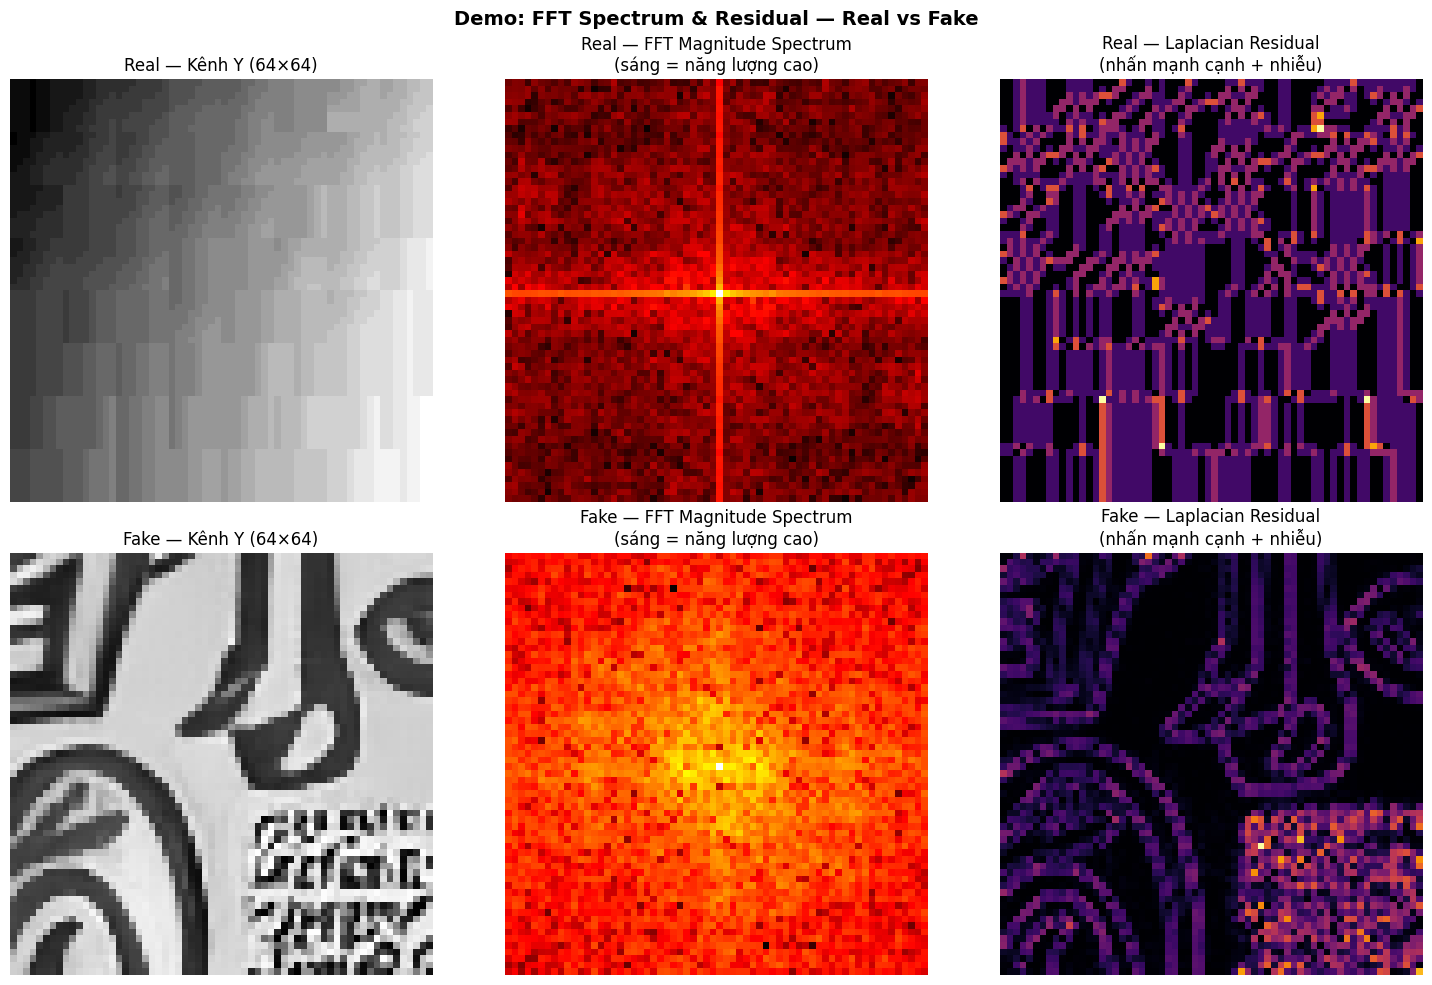


=== FFT Features ===
  Real: {'fft_low_energy': np.float64(3.851512886344402), 'fft_mid_energy': np.float64(2.699154369520953), 'fft_high_energy': np.float64(2.345336363605465), 'fft_high_low_ratio': np.float64(0.6089389891073705)}
  Fake: {'fft_low_energy': np.float64(8.65753048225547), 'fft_mid_energy': np.float64(7.6170344472006875), 'fft_high_energy': np.float64(6.976878327199797), 'fft_high_low_ratio': np.float64(0.8058739546362631)}

=== GLCM Features ===
  Real: {'glcm_contrast': np.float64(0.04195011337868481), 'glcm_homogeneity': np.float64(0.9790249433106577), 'glcm_energy': np.float64(0.5816111893939138), 'glcm_correlation': np.float64(0.959094223348346)}
  Fake: {'glcm_contrast': np.float64(69.27014833711272), 'glcm_homogeneity': np.float64(0.4696857116839367), 'glcm_energy': np.float64(0.1546732418334738), 'glcm_correlation': np.float64(0.636958222717235)}

=== Residual Features ===
  Real: {'residual_std': np.float64(1.2013989241713179), 'residual_mean': np.float64(0.869

In [2]:
# === 1.1 Load 1 ảnh real + 1 ảnh fake để demo ===

df_train = pd.read_csv(os.path.join(PROC_DIR, "manifest_train.csv"))
print(f"Train set: {len(df_train)} ảnh")

# Lấy 1 real và 1 fake
sample_real = df_train[df_train['label'] == 0].iloc[0]
sample_fake = df_train[df_train['label'] == 1].iloc[0]

img_real = cv2.imread(sample_real['path'])
img_fake = cv2.imread(sample_fake['path'])

print(f"Real: {sample_real['generator']} — {sample_real['filename']}")
print(f"Fake: {sample_fake['generator']} — {sample_fake['filename']}")

# Lấy 1 patch từ mỗi ảnh (patch góc trên trái)
patch_real = img_real[:PATCH_SIZE, :PATCH_SIZE]
patch_fake = img_fake[:PATCH_SIZE, :PATCH_SIZE]

# === DEMO FFT ===
from scipy.fft import fft2, fftshift

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (patch, label) in enumerate([(patch_real, "Real"), (patch_fake, "Fake")]):
    patch_y = patch[:, :, 0]  # Kênh Y
    
    # Ảnh kênh Y
    axes[row, 0].imshow(patch_y, cmap='gray')
    axes[row, 0].set_title(f"{label} — Kênh Y (64×64)")
    
    # FFT magnitude spectrum
    f_transform = fft2(patch_y.astype(np.float64))
    f_shift = fftshift(f_transform)
    magnitude = np.log1p(np.abs(f_shift))
    
    axes[row, 1].imshow(magnitude, cmap='hot')
    axes[row, 1].set_title(f"{label} — FFT Magnitude Spectrum\n(sáng = năng lượng cao)")
    
    # Residual (Laplacian)
    residual = cv2.Laplacian(patch_y.astype(np.float64), cv2.CV_64F)
    axes[row, 2].imshow(np.abs(residual), cmap='inferno')
    axes[row, 2].set_title(f"{label} — Laplacian Residual\n(nhấn mạnh cạnh + nhiễu)")

for ax in axes.flat:
    ax.axis('off')
    
plt.suptitle("Demo: FFT Spectrum & Residual — Real vs Fake", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# In features số
print("\n=== FFT Features ===")
print(f"  Real: {extract_fft_features(patch_real[:,:,0])}")
print(f"  Fake: {extract_fft_features(patch_fake[:,:,0])}")

print("\n=== GLCM Features ===")
print(f"  Real: {extract_glcm_features(patch_real[:,:,0])}")
print(f"  Fake: {extract_glcm_features(patch_fake[:,:,0])}")

print("\n=== Residual Features ===")
print(f"  Real: {extract_residual_features(patch_real[:,:,0])}")
print(f"  Fake: {extract_residual_features(patch_fake[:,:,0])}")

print("\n=== Color Correlation Features ===")
print(f"  Real: {extract_color_features(patch_real)}")
print(f"  Fake: {extract_color_features(patch_fake)}")

print("\n=== Statistical Features ===")
print(f"  Real: {extract_stat_features(patch_real[:,:,0])}")
print(f"  Fake: {extract_stat_features(patch_fake[:,:,0])}")

---
## Phần 2: Trích xuất đặc trưng toàn bộ dữ liệu

### Quy trình cho mỗi ảnh:
1. Đọc ảnh processed (256×256 YCrCb)
2. Chia thành 16 patches (4×4 grid, mỗi patch 64×64)
3. Trích 19 features cơ bản từ mỗi patch (FFT: 4, GLCM: 4, Residual: 4, Color: 3, Stat: 4)
4. Gộp 16 patches bằng mean, std, p90 → 19 × 3 = **57 features** cho 1 ảnh

Dùng **multiprocessing** (joblib) để tăng tốc vì số ảnh lớn.

In [3]:
# === 2.1 Hàm trích features cho 1 ảnh (dùng cho parallel) ===

def process_one_image(row):
    """Đọc 1 ảnh → trích features → return dict hoặc None."""
    try:
        img = cv2.imread(row["path"])
        if img is None:
            return None
        features = extract_image_features(img, patch_size=PATCH_SIZE)
        features["label"] = row["label"]
        features["generator"] = row["generator"]
        return features
    except Exception:
        return None

# === 2.2 Trích features cho TRAIN set ===
print("Đang trích xuất features cho TRAIN set...")
df_train = pd.read_csv(os.path.join(PROC_DIR, "manifest_train.csv"))

train_rows = [row for _, row in df_train.iterrows()]
train_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(process_one_image)(row) for row in train_rows
)

# Lọc None
train_features = [r for r in train_results if r is not None]
print(f"Train: {len(train_features)}/{len(df_train)} ảnh trích thành công")

df_train_feat = pd.DataFrame(train_features)
print(f"Shape: {df_train_feat.shape}")

Đang trích xuất features cho TRAIN set...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 156 tasks      | elapsed:    2.8s
[Parallel(n_jobs=4)]: Done 516 tasks      | elapsed:    7.1s
[Parallel(n_jobs=4)]: Done 1020 tasks      | elapsed:   12.8s
[Parallel(n_jobs=4)]: Done 1668 tasks      | elapsed:   20.2s
[Parallel(n_jobs=4)]: Done 2460 tasks      | elapsed:   29.3s
[Parallel(n_jobs=4)]: Done 3396 tasks      | elapsed:   39.7s
[Parallel(n_jobs=4)]: Done 4476 tasks      | elapsed:   52.0s
[Parallel(n_jobs=4)]: Done 5700 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 7068 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done 8580 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 10236 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done 12036 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 13980 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done 16068 tasks      | elapsed:  3

Train: 69060/69060 ảnh trích thành công
Shape: (69060, 59)


In [4]:
# === 2.3 Trích features cho TEST set ===
print("Đang trích xuất features cho TEST set...")
df_test = pd.read_csv(os.path.join(PROC_DIR, "manifest_test.csv"))

test_rows = [row for _, row in df_test.iterrows()]
test_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(process_one_image)(row) for row in test_rows
)

test_features = [r for r in test_results if r is not None]
print(f"Test: {len(test_features)}/{len(df_test)} ảnh trích thành công")

df_test_feat = pd.DataFrame(test_features)
print(f"Shape: {df_test_feat.shape}")

Đang trích xuất features cho TEST set...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 216 tasks      | elapsed:    2.5s
[Parallel(n_jobs=4)]: Done 576 tasks      | elapsed:    6.6s
[Parallel(n_jobs=4)]: Done 1080 tasks      | elapsed:   12.4s
[Parallel(n_jobs=4)]: Done 1728 tasks      | elapsed:   19.7s
[Parallel(n_jobs=4)]: Done 2520 tasks      | elapsed:   28.8s
[Parallel(n_jobs=4)]: Done 3456 tasks      | elapsed:   39.9s
[Parallel(n_jobs=4)]: Done 4536 tasks      | elapsed:   52.2s
[Parallel(n_jobs=4)]: Done 5760 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 7128 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done 8640 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 10296 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done 12096 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 14040 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done 16128 tasks      | elapsed:  3

Test: 17266/17266 ảnh trích thành công
Shape: (17266, 59)


[Parallel(n_jobs=4)]: Done 17266 out of 17266 | elapsed:  3.3min finished


## Phần 3: Lưu features & Kiểm tra chất lượng

In [5]:
# === 3.1 Tách X, y và lưu ===

# Tên features (bỏ label, generator)
feature_cols = [c for c in df_train_feat.columns if c not in ["label", "generator"]]

X_train = df_train_feat[feature_cols].values.astype(np.float64)
y_train = df_train_feat["label"].values.astype(np.int32)
X_test = df_test_feat[feature_cols].values.astype(np.float64)
y_test = df_test_feat["label"].values.astype(np.int32)

# Kiểm tra NaN / Inf
print("Kiểm tra dữ liệu:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  NaN trong X_train: {np.isnan(X_train).sum()}")
print(f"  Inf trong X_train: {np.isinf(X_train).sum()}")
print(f"  NaN trong X_test:  {np.isnan(X_test).sum()}")
print(f"  Inf trong X_test:  {np.isinf(X_test).sum()}")

# Xử lý NaN/Inf nếu có (thay bằng 0)
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Lưu
np.save(os.path.join(FEATURE_DIR, "X_train.npy"), X_train)
np.save(os.path.join(FEATURE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(FEATURE_DIR, "X_test.npy"), X_test)
np.save(os.path.join(FEATURE_DIR, "y_test.npy"), y_test)

# Lưu tên features
with open(os.path.join(FEATURE_DIR, "feature_names.txt"), "w") as f:
    f.write("\n".join(feature_cols))

# Lưu generator info cho phân tích per-generator
df_train_feat[["label", "generator"]].to_csv(
    os.path.join(FEATURE_DIR, "train_meta.csv"), index=False)
df_test_feat[["label", "generator"]].to_csv(
    os.path.join(FEATURE_DIR, "test_meta.csv"), index=False)

print(f"\n✓ Đã lưu vào {FEATURE_DIR}/")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Features: {len(feature_cols)}")

Kiểm tra dữ liệu:
  X_train shape: (69060, 57)
  X_test shape:  (17266, 57)
  NaN trong X_train: 3411
  Inf trong X_train: 0
  NaN trong X_test:  810
  Inf trong X_test:  0

✓ Đã lưu vào E:\ai_image_detector\features/
  X_train: (69060, 57)
  X_test:  (17266, 57)
  Features: 57


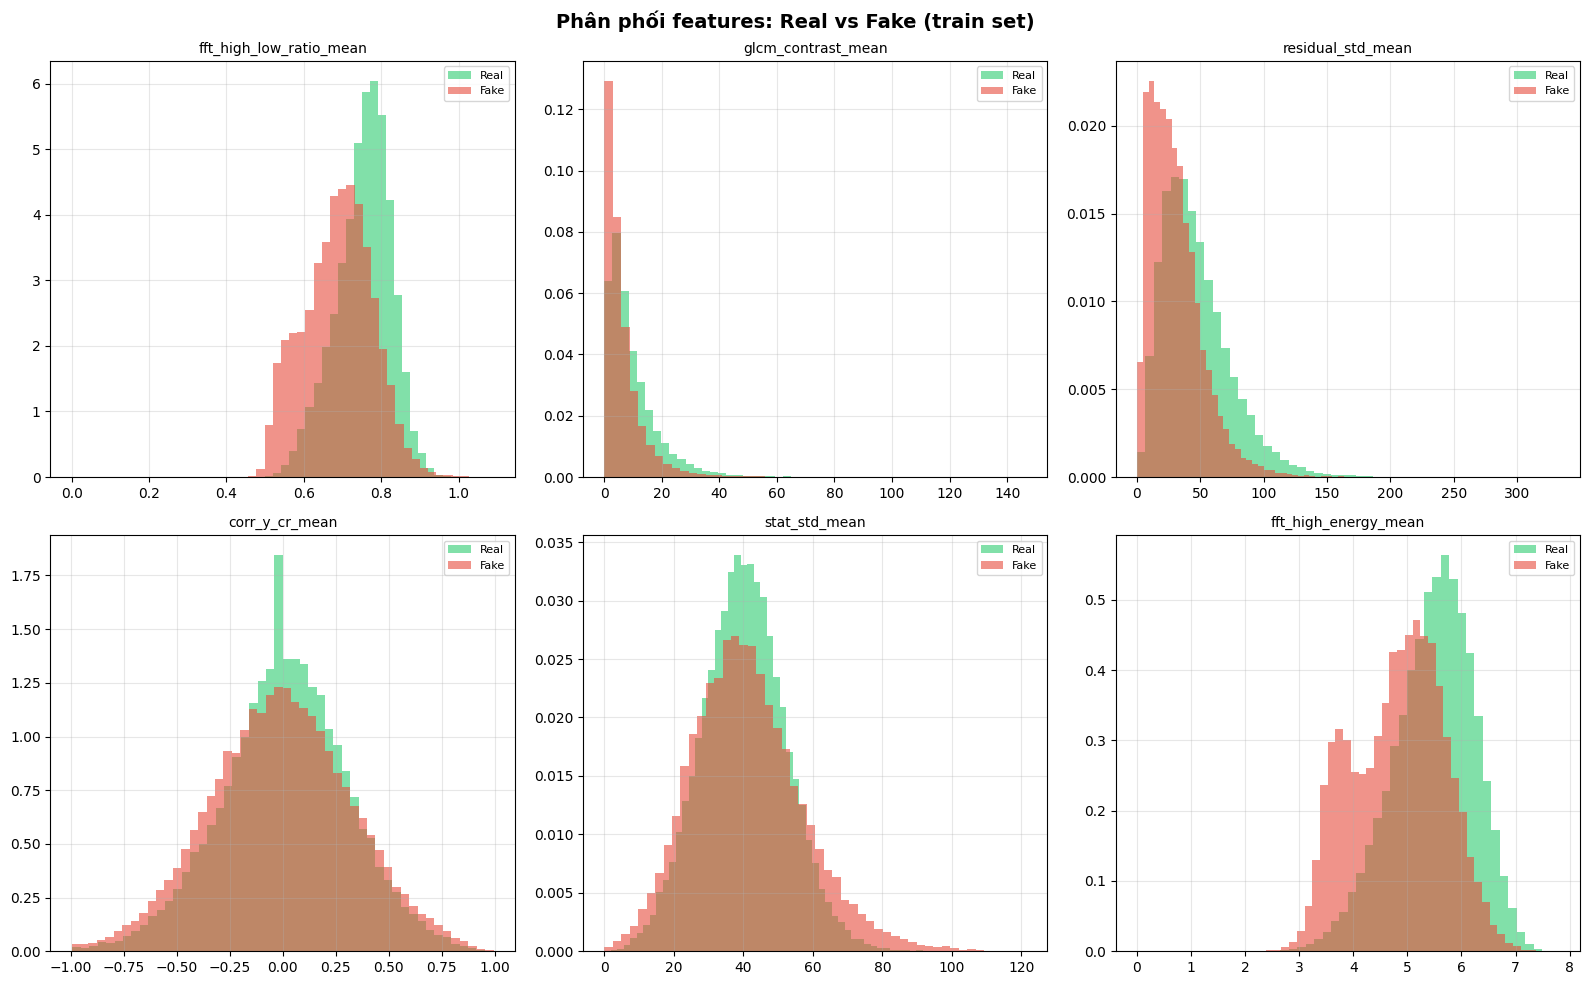

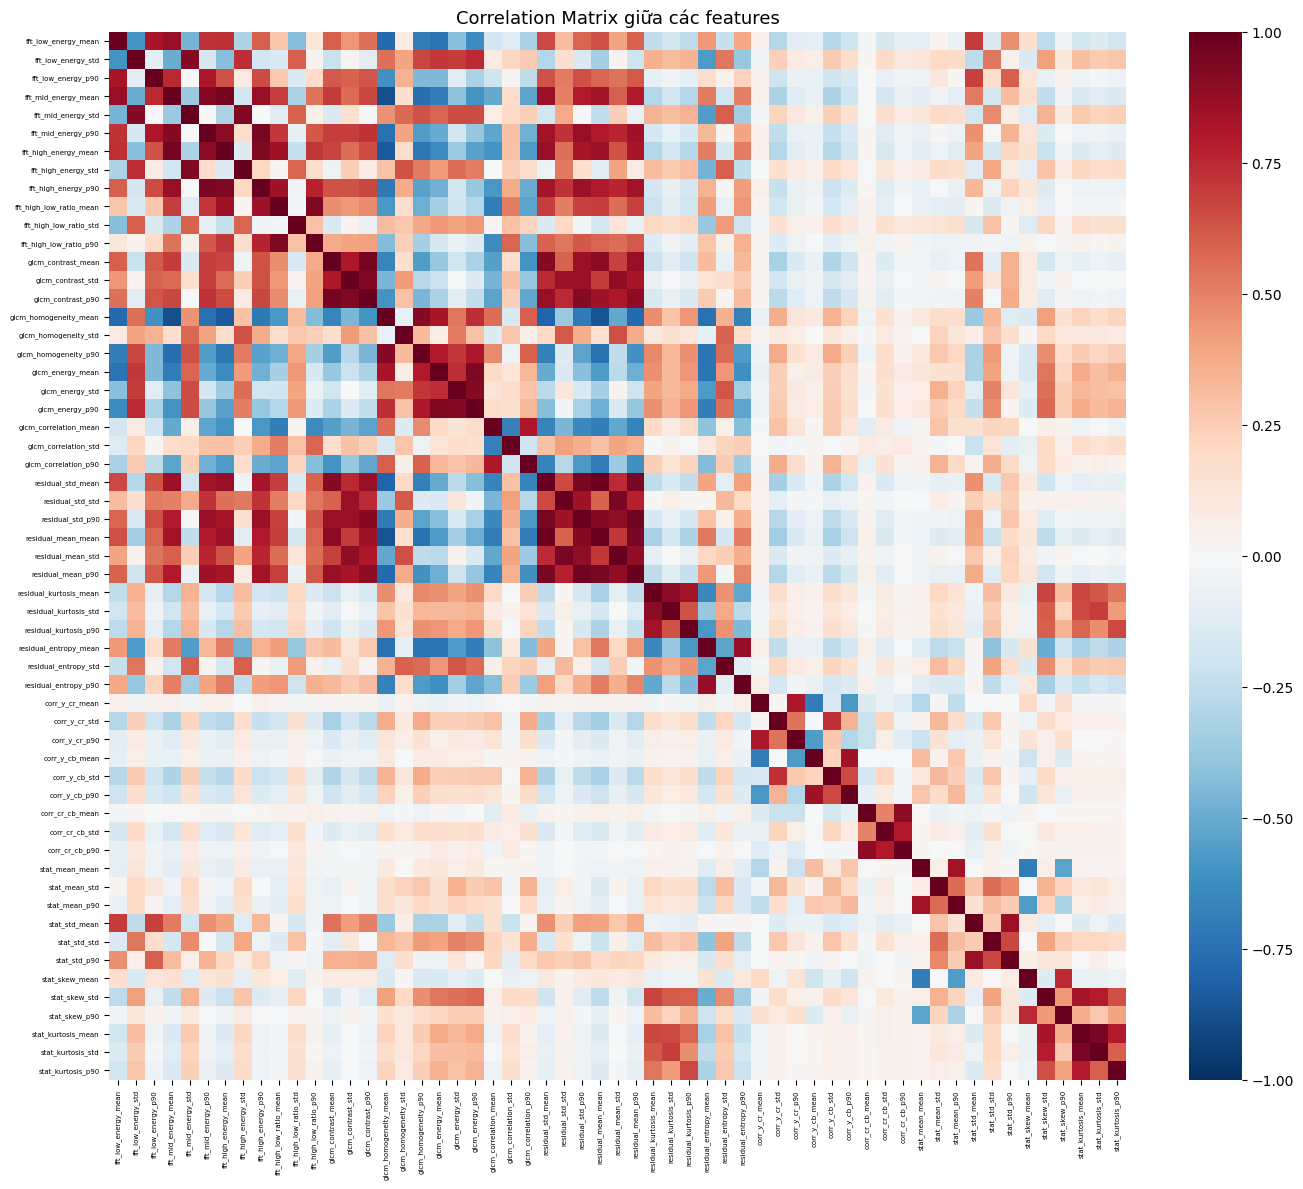

✓ Feature extraction hoàn tất. Sẵn sàng cho Notebook 03 (Training).


In [6]:
# === 3.2 Phân phối features: Real vs Fake ===

# Chọn 6 features tiêu biểu để visualize
show_features = [
    "fft_high_low_ratio_mean", "glcm_contrast_mean", "residual_std_mean",
    "corr_y_cr_mean", "stat_std_mean", "fft_high_energy_mean"
]
# Lọc features có trong data
show_features = [f for f in show_features if f in feature_cols]

if show_features:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for idx, feat in enumerate(show_features[:6]):
        ax = axes[idx // 3, idx % 3]
        feat_idx = feature_cols.index(feat)
        
        real_vals = X_train[y_train == 0, feat_idx]
        fake_vals = X_train[y_train == 1, feat_idx]
        
        ax.hist(real_vals, bins=50, alpha=0.6, label="Real", color="#2ecc71", density=True)
        ax.hist(fake_vals, bins=50, alpha=0.6, label="Fake", color="#e74c3c", density=True)
        ax.set_title(feat, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    plt.suptitle("Phân phối features: Real vs Fake (train set)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# === Correlation matrix ===
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = np.corrcoef(X_train.T)
sns.heatmap(corr_matrix, xticklabels=feature_cols, yticklabels=feature_cols,
            cmap='RdBu_r', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix giữa các features", fontsize=13)
plt.xticks(fontsize=5, rotation=90)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

print(f"✓ Feature extraction hoàn tất. Sẵn sàng cho Notebook 03 (Training).")

---
## Phần 4: Snapshot dữ liệu trước khi mô hình học (xuất CSV để báo cáo)

Mục tiêu phần này là chuyển một phần dữ liệu `.npy` sang CSV để dễ trình bày trong Word:
- `X_train_preview_500.csv`, `X_test_preview_500.csv`
- `model_input_summary.csv`
- `feature_stats_summary.csv`

Các file preview giúp minh họa rõ: **1 dòng = 1 ảnh**, gồm meta + nhãn + vector feature.

In [ ]:
# === 4.1 Xuất CSV preview từ .npy + meta ===

CSV_DIR = os.path.join(FEATURE_DIR, "csv_exports")
os.makedirs(CSV_DIR, exist_ok=True)

# Đảm bảo dùng đúng danh sách tên cột
if os.path.exists(os.path.join(FEATURE_DIR, "feature_names.txt")):
    with open(os.path.join(FEATURE_DIR, "feature_names.txt"), "r", encoding="utf-8") as f:
        feature_cols_saved = [x.strip() for x in f.readlines() if x.strip()]
else:
    feature_cols_saved = feature_cols

# Nếu vì lý do nào đó tên cột không khớp số chiều, fallback theo feature_cols hiện tại
if len(feature_cols_saved) != X_train.shape[1]:
    print("⚠️ feature_names.txt không khớp số chiều, dùng feature_cols trong bộ nhớ.")
    feature_cols_saved = feature_cols

# Tạo DataFrame feature
X_train_df = pd.DataFrame(X_train, columns=feature_cols_saved)
X_test_df = pd.DataFrame(X_test, columns=feature_cols_saved)

y_train_s = pd.Series(y_train, name="y")
y_test_s = pd.Series(y_test, name="y")

train_meta_path = os.path.join(FEATURE_DIR, "train_meta.csv")
test_meta_path = os.path.join(FEATURE_DIR, "test_meta.csv")

train_meta = pd.read_csv(train_meta_path) if os.path.exists(train_meta_path) else pd.DataFrame()
test_meta = pd.read_csv(test_meta_path) if os.path.exists(test_meta_path) else pd.DataFrame()

train_full = pd.concat([train_meta.reset_index(drop=True), y_train_s, X_train_df], axis=1)
test_full = pd.concat([test_meta.reset_index(drop=True), y_test_s, X_test_df], axis=1)

train_preview_path = os.path.join(CSV_DIR, "X_train_preview_500.csv")
test_preview_path = os.path.join(CSV_DIR, "X_test_preview_500.csv")

train_full.head(500).to_csv(train_preview_path, index=False)
test_full.head(500).to_csv(test_preview_path, index=False)

print(f"✓ Saved: {train_preview_path}")
print(f"✓ Saved: {test_preview_path}")
print(f"Train full shape (meta+y+features): {train_full.shape}")
print(f"Test  full shape (meta+y+features): {test_full.shape}")

train_full.head(5)

In [ ]:
# === 4.2 Tạo model_input_summary.csv và feature_stats_summary.csv ===

summary_rows = [
    {"metric": "X_train_rows", "value": int(X_train.shape[0])},
    {"metric": "X_train_features", "value": int(X_train.shape[1])},
    {"metric": "X_test_rows", "value": int(X_test.shape[0])},
    {"metric": "X_test_features", "value": int(X_test.shape[1])},
    {"metric": "y_train_positive", "value": int((y_train == 1).sum())},
    {"metric": "y_train_negative", "value": int((y_train == 0).sum())},
    {"metric": "y_test_positive", "value": int((y_test == 1).sum())},
    {"metric": "y_test_negative", "value": int((y_test == 0).sum())},
]

df_model_summary = pd.DataFrame(summary_rows)
model_summary_path = os.path.join(CSV_DIR, "model_input_summary.csv")
df_model_summary.to_csv(model_summary_path, index=False)

# Feature stats cho báo cáo (mean/std/min/max trên train)
feature_stats = pd.DataFrame({
    "feature_name": feature_cols_saved,
    "mean": np.mean(X_train, axis=0),
    "std": np.std(X_train, axis=0),
    "min": np.min(X_train, axis=0),
    "max": np.max(X_train, axis=0),
})

feature_stats_path = os.path.join(CSV_DIR, "feature_stats_summary.csv")
feature_stats.to_csv(feature_stats_path, index=False)

print(f"✓ Saved: {model_summary_path}")
print(f"✓ Saved: {feature_stats_path}")
print("\nModel input summary:")
print(df_model_summary.to_string(index=False))

print("\nFeature stats preview:")
feature_stats.head(10)